<a href="https://colab.research.google.com/github/mana-1538/AI_ML-practice-projects/blob/main/TitanicDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.dtypes


,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


Text(0.5, 1.0, 'Missing Value Heatmap ')

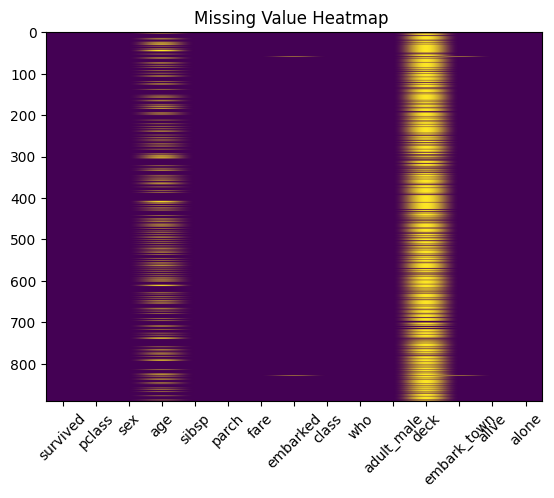

In [ ]:
plt.imshow(df.isnull().astype(int),aspect ='auto')
plt.xticks(range(len(df.columns)), df.columns, rotation=45)
plt.title('Missing Value Heatmap ')


In [ ]:
# missing values in age
# embarked,embark_town  - very few missing values , these rows can be filled with the most common value
# deck - too many missing values - this column is not having much significance - can be dropped
# some columns are repeated like sex/adult_male , survived/alive, pclass/class , embark/embarked_town- we will keep only one of them
# convert data in boolean format
# for regression convert sibsp and parch into family size

In [ ]:
drop_cols = ['deck','sex','alive','class','embark_town','who']
df.drop(columns =drop_cols,inplace=True)

In [ ]:
df['embarked'].value_counts()

,count
embarked,
S,644
C,168
Q,77


In [ ]:
df['age']=df['age'].fillna(df['age'].mean())
df['embarked']=df['embarked'].fillna(df['embarked'].mode()[0])
df[['adult_male','alone']]=df[['adult_male','alone']].astype(int)
df['family_size']=df['sibsp']+df['parch']
df.drop(columns=['sibsp','parch'],inplace =True)
df['embarked']=df['embarked'].map({'S':1,'C':2,'Q':3})

In [ ]:
df.describe()

,survived,pclass,age,fare,embarked,adult_male,alone,family_size
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,32.204208,1.361392,0.602694,0.602694,0.904602
std,0.486592,0.836071,13.002015,49.693429,0.635673,0.489615,0.489615,1.613459
min,0.000000,1.000000,0.420000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,7.910400,1.000000,0.000000,0.000000,0.000000
50%,0.000000,3.000000,29.699118,14.454200,1.000000,1.000000,1.000000,0.000000
75%,1.000000,3.000000,35.000000,31.000000,2.000000,1.000000,1.000000,1.000000
max,1.000000,3.000000,80.000000,512.329200,3.000000,1.000000,1.000000,10.000000


In [ ]:
df.head()

,survived,pclass,age,fare,embarked,adult_male,alone,family_size
0,0,3,22.0,7.2500,1,1,0,1
1,1,1,38.0,71.2833,2,0,0,1
2,1,3,26.0,7.9250,1,0,1,0
3,1,1,35.0,53.1000,1,0,0,1
4,0,3,35.0,8.0500,1,1,1,0


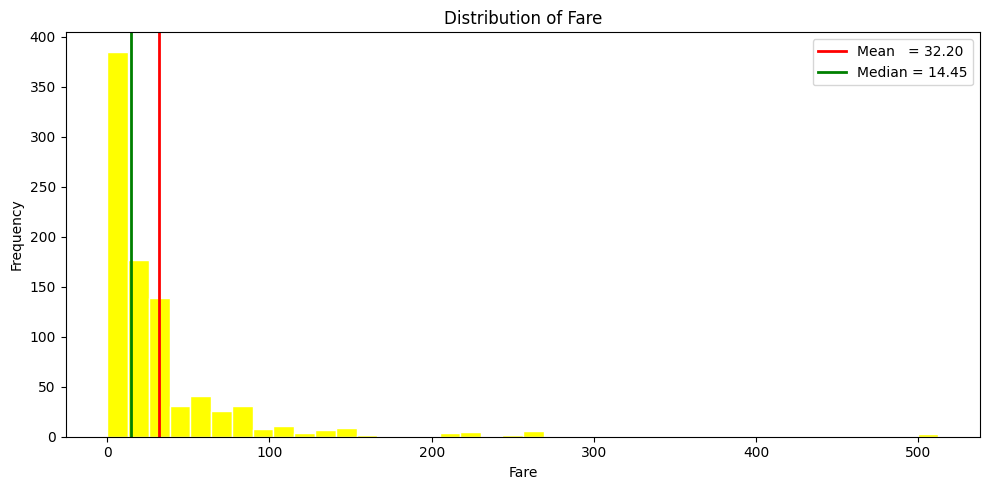

In [ ]:
# task -3

mean_val   = df['fare'].mean()
median_val = df['fare'].median()

plt.figure(figsize=(10, 5))
plt.hist(df['fare'], bins = 40, color='yellow', edgecolor='white')

plt.axvline(mean_val, color = 'red', lw = 2, label=f'Mean   = {mean_val:.2f}')
plt.axvline(median_val, color = 'green', lw = 2, label=f'Median = {median_val:.2f}')

plt.title('Distribution of Fare', fontsize=12)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#as mean greater than median , it is right skewed, it shows that most people bought cheaper tickets, while only a few bought tickets with higher prices

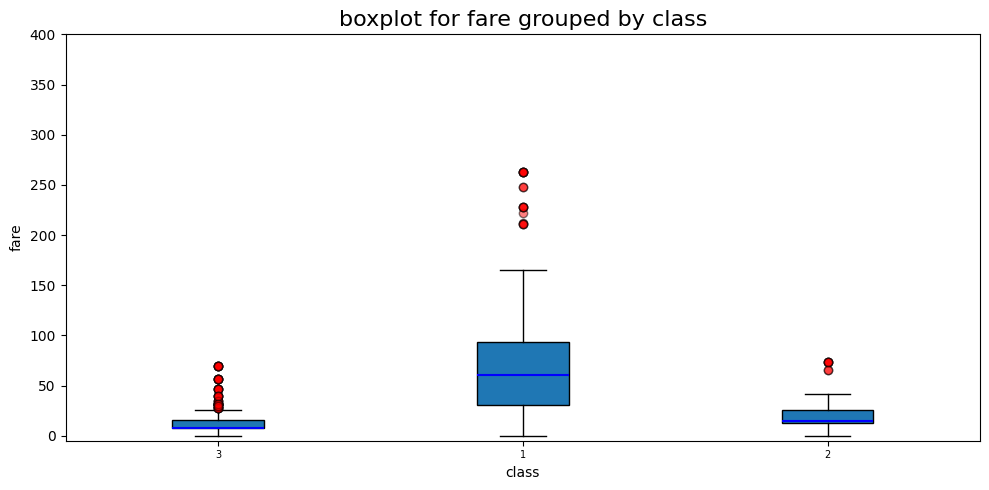

In [ ]:
#task 4
d = [df[df['pclass'] == clas]['fare'].values for clas in df['pclass'].unique()]

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(d, medianprops=dict(color='blue', linewidth=1.5),patch_artist=True,flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.5})

ax.set_xticklabels(df['pclass'].unique(), fontsize=7)
ax.set_title('boxplot for fare grouped by class', fontsize=16)
ax.set_xlabel('class')
ax.set_ylabel('fare')
ax.set_ylim(-5, 400)
plt.tight_layout()
plt.show()


Text(0, 0.5, 'class')

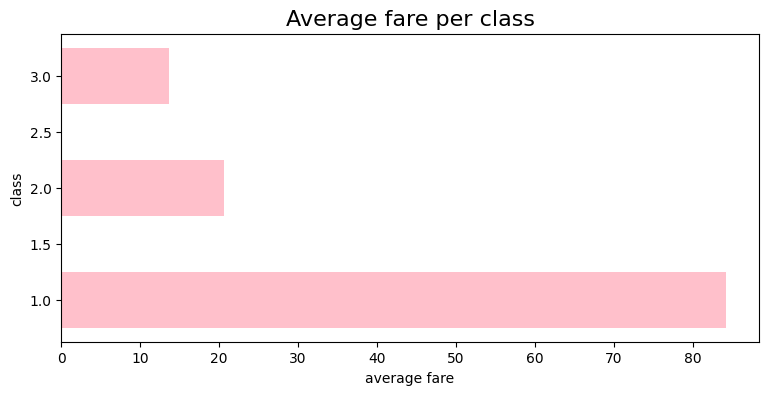

In [ ]:
#task-5
avg_fare = (df.groupby('pclass')['fare'].mean().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(9,4))

bars = ax.barh(avg_fare.index, avg_fare.values,height = 0.5, color='pink',align ='center')

ax.set_title('Average fare per class', fontsize=16)
ax.set_xlabel('average fare')
ax.set_ylabel('class')

pearson correlation coefficient is 0.0916


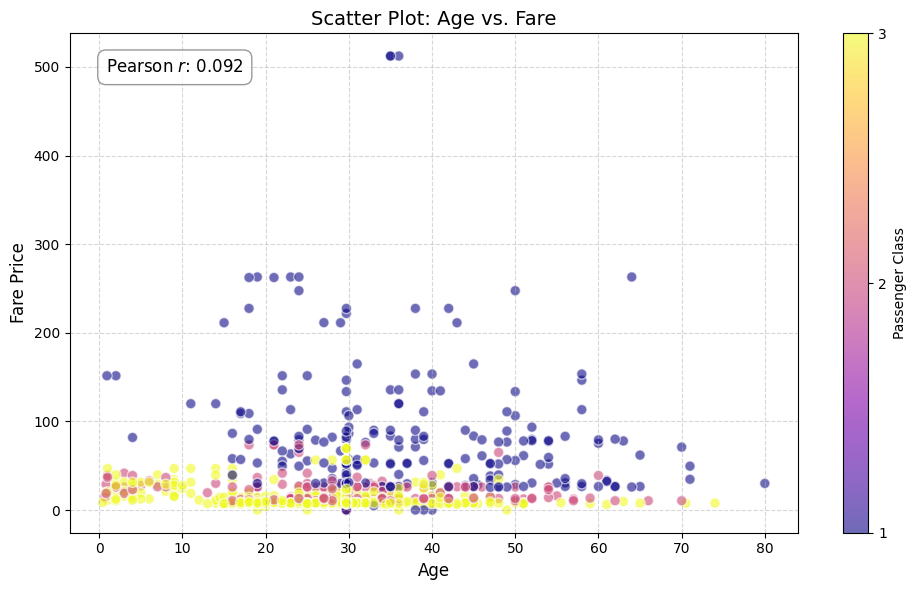

In [ ]:
#task -6
coeff = np.corrcoef(df['age'],df['fare'])[0,1]
print(f"pearson correlation coefficient is {coeff:.4f}")
fig,ax = plt.subplots(figsize=(10,6))
scatter = ax.scatter(
    df['age'],
    df['fare'],
    c=df['pclass'],
    cmap='plasma',
    alpha=0.6,
    edgecolors='w',
    s=55
)

#adding pearson coefficient in plot -------- had to use a bit of ai here----wasn't able to find the code in documentation :)
text_str = f'Pearson $r$: {coeff:.3f}'
ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))


ax.set_title('Scatter Plot: Age vs. Fare', fontsize=14)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Fare Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Passenger Class')
cbar.set_ticks([1, 2, 3])
plt.tight_layout()
plt.show()

In [ ]:
# pearson coefficient is close to zero - hence weak linear correlation, that is age and fare price have no such linear dependence

[Text(0, 0, 'survived'),
 Text(0, 1, 'pclass'),
 Text(0, 2, 'age'),
 Text(0, 3, 'fare'),
 Text(0, 4, 'embarked'),
 Text(0, 5, 'adult_male'),
 Text(0, 6, 'alone'),
 Text(0, 7, 'family_size')]

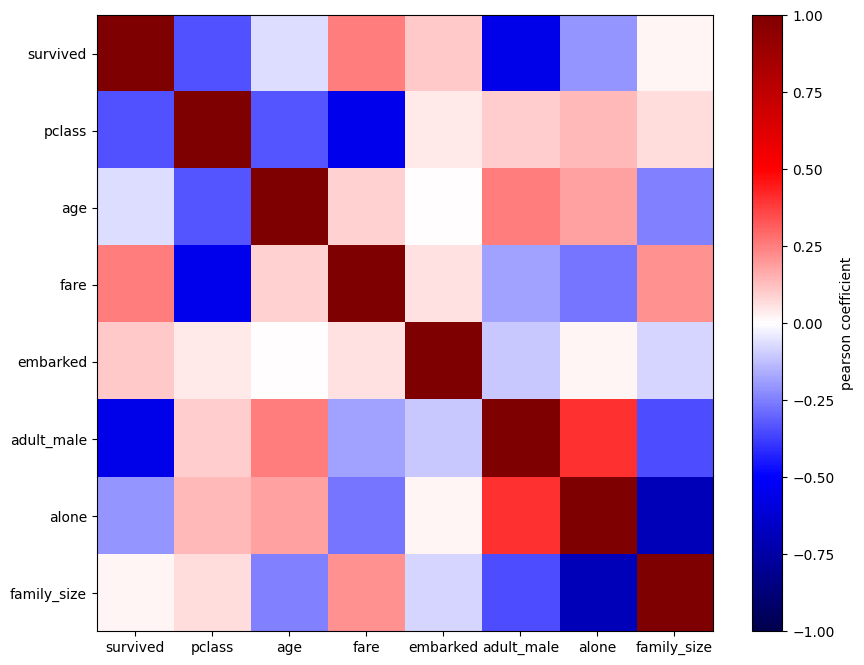

In [ ]:
# task-7
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))

sh = ax.imshow(corr, cmap='seismic', vmin=-1, vmax=1)
plt.colorbar(sh, ax=ax, label='pearson coefficient')

cols = corr.columns
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols)
ax.set_yticklabels(cols)

In [ ]:
# STRONGEST CORRELATION IS OF ADULT_MALE AND ALONE OR SURVIVED AND ADULT_MALE
# WEAKEST CORRELATION IS OF AGE AND EMBARKED OR ALONE AND EMBARKED

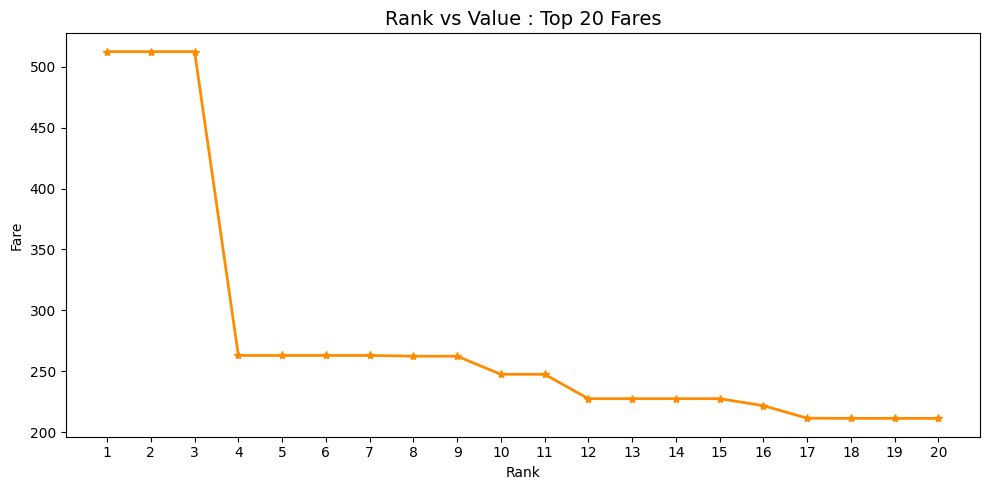

In [ ]:
#TASK -8
# as there is no time-series correlation , we are gonna plot top 20(highest) fare prices
top = df['fare'].sort_values(ascending=False).head(20)
ranks =range(1,21)
fig,ax =plt.subplots(figsize=(10,5))
ax.plot(ranks, top, marker='*', color='darkorange', linewidth=2, markersize=6, label='Fare')
ax.set_title('Rank vs Value : Top 20 Fares',fontsize=14)
ax.set_xlabel('Rank')
ax.set_ylabel('Fare')
ax.set_xticks(ranks)

plt.tight_layout()
plt.show()

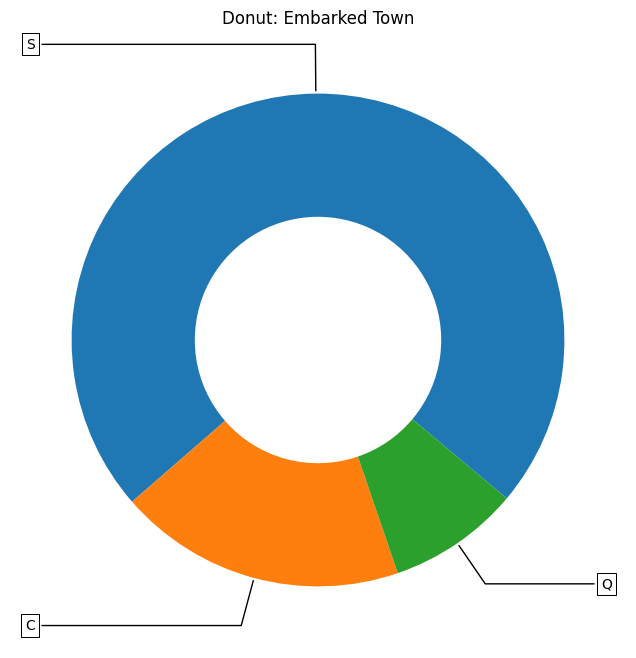

In [ ]:
# task -9
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(aspect="equal"))
data = df['embarked'].value_counts()
label =['S','C','Q']
wedges, texts = ax.pie(data, wedgeprops={'width': 0.5}, startangle=-40)
bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(label[i], xy=(x, y), xytext=(1.15*np.sign(x), 1.2*y),
                horizontalalignment=horizontalalignment, **kw)
ax.set_title('Donut: Embarked Town')
plt.show()

In [ ]:
# HERE THE DATA WAS LESS , SO PIE CHART IS CLEAR , IF THERE ARE VARIOUS CATEGORIES THEN A DONUT MAY LOOK MESSY , IN THAT CASE BAR GRAPH LOOKS CLEARER

Text(0.5, 1.0, 'Donut: Embarked Town')

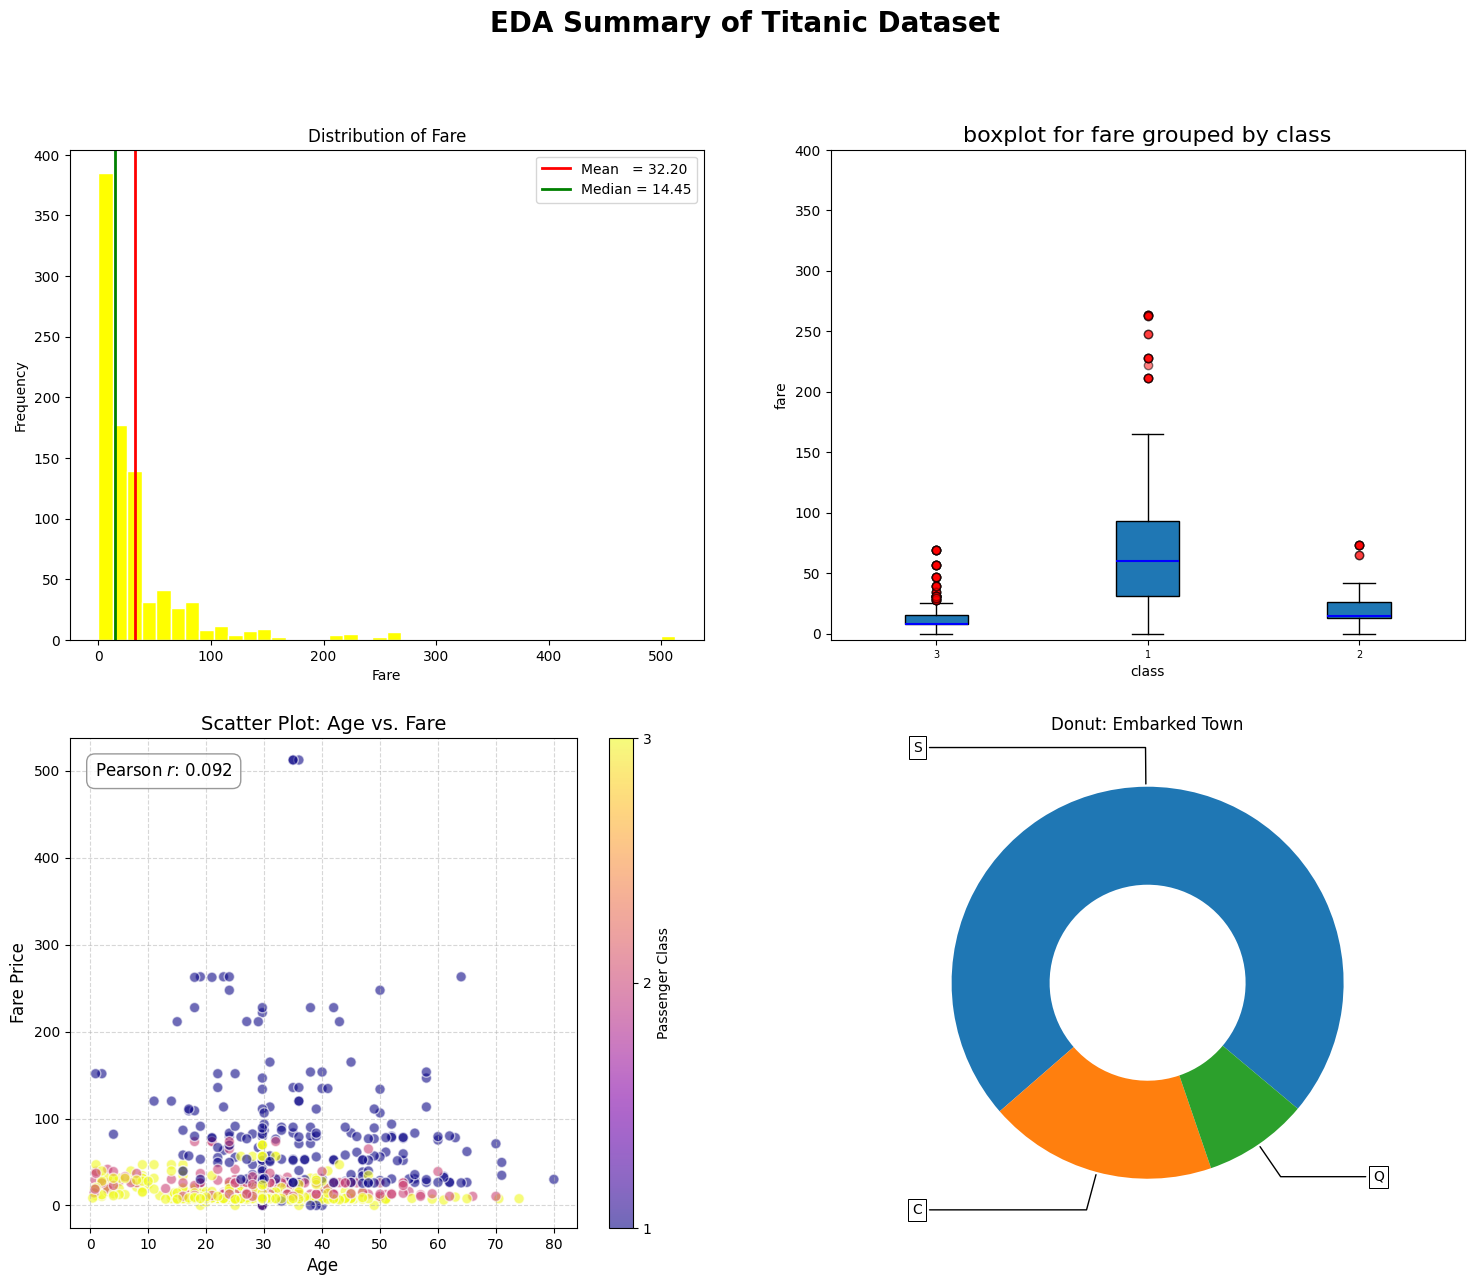

In [ ]:
fig,axes = plt.subplots(2,2,figsize=(18,14))
fig.suptitle('EDA Summary of Titanic Dataset',fontsize = 20,fontweight='bold')

# HISTOGRAM
ax=axes[0,0]
mean_val   = df['fare'].mean()
median_val = df['fare'].median()


ax.hist(df['fare'], bins = 40, color='yellow', edgecolor='white')

ax.axvline(mean_val, color = 'red', lw = 2, label=f'Mean   = {mean_val:.2f}')
ax.axvline(median_val, color = 'green', lw = 2, label=f'Median = {median_val:.2f}')

ax.set_title('Distribution of Fare', fontsize=12)
ax.set_xlabel('Fare')
ax.set_ylabel('Frequency')
ax.legend()


# BOXPLOT

ax = axes[0,1]
d = [df[df['pclass'] == clas]['fare'].values for clas in df['pclass'].unique()]

bp = ax.boxplot(d, medianprops=dict(color='blue', linewidth=1.5),patch_artist=True,flierprops={'marker': 'o', 'markerfacecolor': 'red', 'alpha': 0.5})

ax.set_xticklabels(df['pclass'].unique(), fontsize=7)
ax.set_title('boxplot for fare grouped by class', fontsize=16)
ax.set_xlabel('class')
ax.set_ylabel('fare')
ax.set_ylim(-5, 400)


# SCATTER PLOT
ax=axes[1,0]
coeff = np.corrcoef(df['age'],df['fare'])[0,1]

scatter = ax.scatter(
    df['age'],
    df['fare'],
    c=df['pclass'],
    cmap='plasma',
    alpha=0.6,
    edgecolors='w',
    s=55
)

#adding pearson coefficient in plot -------- had to use a bit of ai here----wasn't able to find the code in documentation :)
text_str = f'Pearson $r$: {coeff:.3f}'
ax.text(0.05, 0.95, text_str, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))


ax.set_title('Scatter Plot: Age vs. Fare', fontsize=14)
ax.set_xlabel('Age', fontsize=12)
ax.set_ylabel('Fare Price', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label('Passenger Class')
cbar.set_ticks([1, 2, 3])

# DONUT
ax=axes[1,1]
data = df['embarked'].value_counts()
label =['S','C','Q']
wedges, texts = ax.pie(data, wedgeprops={'width': 0.5}, startangle=-40)
bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")
for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(label[i], xy=(x, y), xytext=(1.15*np.sign(x), 1.2*y),
                horizontalalignment=horizontalalignment, **kw)
ax.set_title('Donut: Embarked Town')



In [ ]:
fig.savefig('summary.png', dpi=150, bbox_inches='tight')


In [ ]:
# task - 11
fare = df['fare']
q1,q3 = np.percentile(data, [25, 75])
iqr = q3-q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

outliers_bool = (fare>upper_bound)| (fare<lower_bound)
outlier_values=fare[outliers_bool]
clean_values = fare[~outliers_bool]

percent_outliers = (len(outlier_values)/len(fare))*100

print(f"25th Percentile (Q1): {q1:.2f}")
print(f"75th Percentile (Q3): {q3:.2f}")
print(f"Lower Bound: {lower_bound:.2f}" )
print(f"Upper Bound: {upper_bound:.2f}")
print(f"count of flagged rows is {len(outlier_values)}")
print(f"percentage of flagged rows is {percent_outliers}")

25th Percentile (Q1): 122.50
75th Percentile (Q3): 407.00
Lower Bound: -304.25
Upper Bound: 833.75
count of flagged rows is 0
percentage of flagged rows is 0.0


In [ ]:
# NO OUTLIERS DETECTED IN FARE COLUMN ----- HENCE NO NEED TO REMOVE ANY ROWS
# HOWEVER IF THE NUMBER OF OUTLIER ROWS ARE FEW - WE REMOVE THEM TO ENHANCE ACCURACY OF MODEL ESLE THESE VALUES FORM A PART OF THE TRAINING DATASET AND AFFECTS OUR MODEL JUDGEMENT


In [ ]:
### LINEAR REGRESSION ###
# FEATURES USED --> FAMILY SIZE , PCLASS , AGE , SURVIVED -- TO PREDICT FARE

In [ ]:
features=['family_size','pclass','age','survived']
target = ['fare']

data=df[features + target].dropna().values.astype(np.float64)
np.random.shuffle(data)

X =data[:,: -1]
Y = data[:,[-1]]


In [ ]:
split=int(0.8*len(X))
X_train,X_test = X[:split],X[split:]
Y_train,Y_test = Y[:split],Y[split:]

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [ ]:
one_train=np.ones((X_train.shape[0],1))
X_bias=np.c_[one_train,X_train]

one_test=np.ones((X_test.shape[0],1))
X_test_bias=np.c_[one_test,X_test]

model = np.linalg.lstsq(X_bias, Y_train, rcond=None)[0]

In [ ]:
y_pred = X_test_bias @ model

mse = np.mean((Y_test - y_pred) ** 2)
res = np.sum((Y_test - y_pred) ** 2)
total = np.sum((Y_test - Y_test.mean()) ** 2)
r2_score = 1 - (res / total)

print(f"MSE : {mse:.4f}")
print(f"R²  : {r2_score:.4f}")

MSE : 1139.5242
R²  : 0.4696


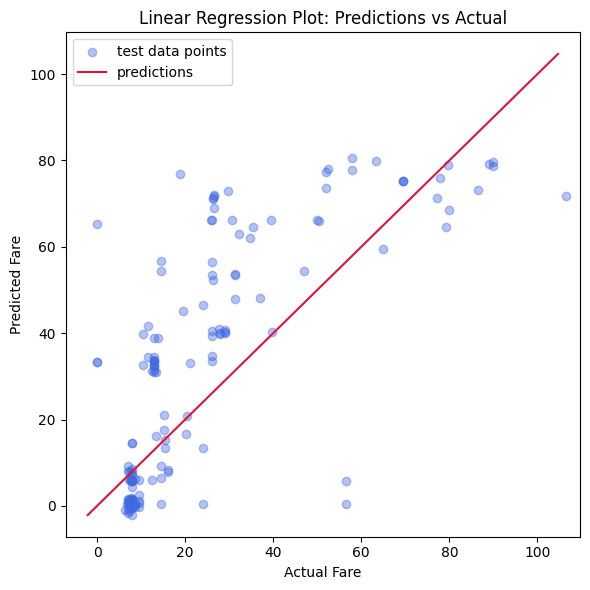

In [ ]:
fig,ax=plt.subplots(figsize = (6,6))
ax.scatter(Y_test,y_pred,color = 'royalblue',alpha = 0.4,label='test data points')

min_val = min(y_pred.min(),Y_test.min())
max_val = max(y_pred.max(),Y_test.min())

ax.plot([min_val,max_val],[min_val,max_val],color='crimson',label='predictions')

ax.set_title('Linear Regression Plot: Predictions vs Actual')
ax.set_xlabel('Actual Fare')
ax.set_ylabel('Predicted Fare')

ax.set_xlim(min_val-5,max_val+5)
ax.set_ylim(min_val-5,max_val+5)
ax.legend()
plt.tight_layout()
plt.show()

firstly we select the features to be used in prediction and the target value . Then drop any remaining Nan values present , shuffle the data points,and split these in train and test . Scaling the dataset using mean and std to prevent false predictions due to inflation in some column values , now mean becomes 0 and std becomes 1. Then adding column containing only ones as bias in the dataset. Implementing simple Linear regression using matrices , making predictions .
Finally calculating losses using mse and r2 values . mse should be close to 0 while r2 values should be close to 1 for a good model , though my accuracy is not so good
  
  Finally plotting the actual vs pred data as a scatter plot which ideally should be linear .


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df[features].values
y = df[target].values

indices = np.arange(len(X))
np.random.shuffle(indices)
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model   = LinearRegression()
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)

mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.4f}")
print(f"R²   : {r2:.4f}")

MSE  : 752.6611
R²   : 0.4672


In [ ]:
# yes , my r2 values are close enough to each other
# here , survived must have the large positive effect and family size  has the lowest positive effect
# adding more features can prolly help in increasing r2 values , although linear regression assumes linear relationship while the fare price of this dataset perhaps is uneven and does not obey a perfect linear relationship with the features and thus the overall accuracy is lower
